Device: cuda
Wczytuję dane Bias (z plików CSV)...
Elektrony Bias: 9006
Miony Bias:     31277
Ładuję model i scaler...
Inferencja...

Accuracy elektrony: 76.72%  (martwa strefa: 431)
Accuracy miony:     98.32%  (martwa strefa: 54)


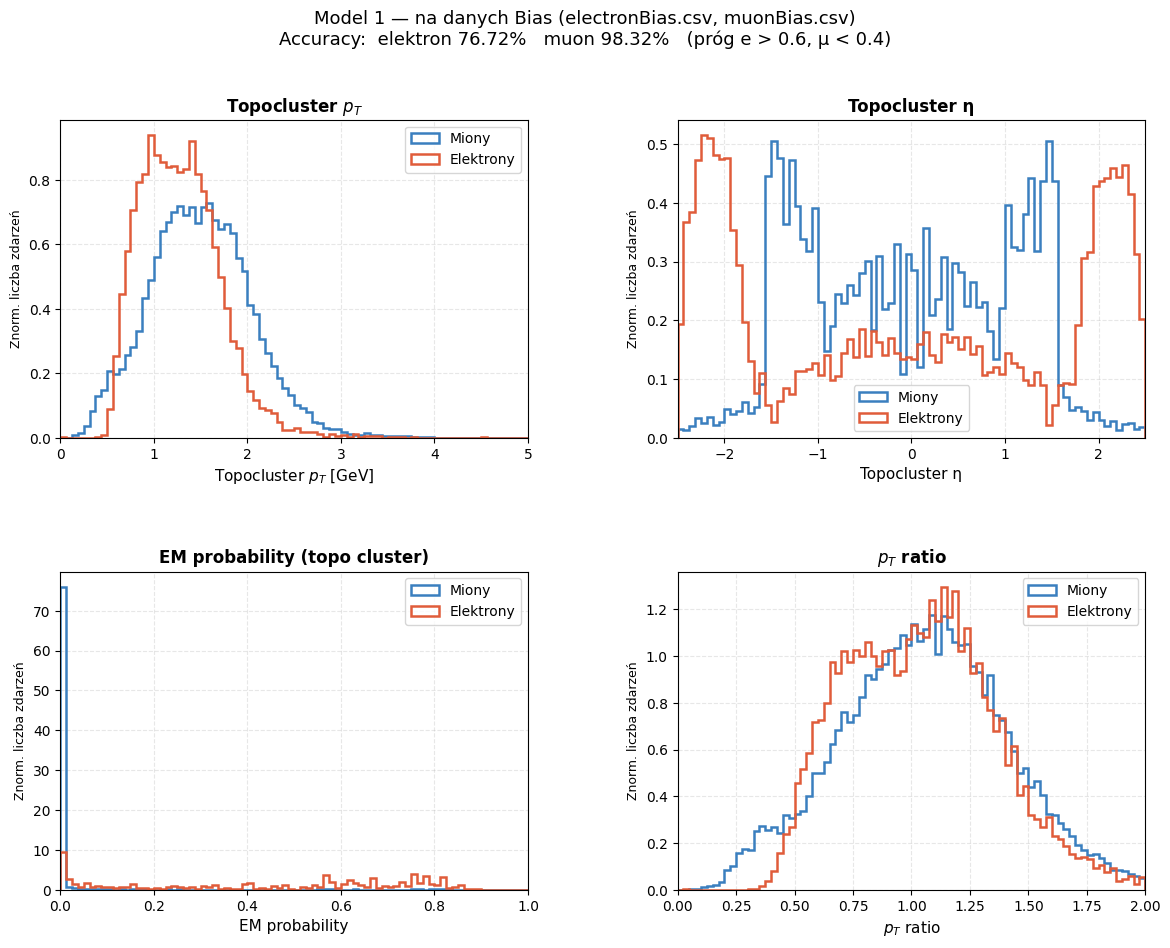

Zapisano: plot_mlp1_bias_csv.png


In [ ]:
import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── konfiguracja ──────────────────────────────────────────────────────────────
ELEC_FILE = "../../../Data_Separated/Bias/electronBias.csv"
MUON_FILE = "../../../Data_Separated/Bias/muonBias.csv"
MODEL_PATH   = "../../klasyfikator/trained/model-filter.pt"
SCALER_PATH  = "../../klasyfikator/trained/scaler_mlp1.pkl"

THRESH_MUON   = 0.4
THRESH_ELEC   = 0.6
MAX_PER_CLASS = 100000

FEATURE_COLUMNS = [
    "track_TRTHits", "track_PixelHits", "track_SCTHits", "track_PixeldEdX",
    "topo_cluster_eta", "topo_cluster_phi", "topo_cluster_EM_prob",
    "topo_cluster_pt", "pt_ratio", "topo_cluster_lambda", "topo_cluster_lambda2"
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ── wczytanie i filtracja ─────────────────────────────────────────────────────
print("Wczytuję dane Bias (z plików CSV)...")
df_el = pd.read_csv(ELEC_FILE)
df_mu = pd.read_csv(MUON_FILE)

FILTER = lambda df: df[
    (df['topo_cluster_eta']    != -10.0) &
    (df['topo_cluster_pt']     !=  -1.0) &
    (df['topo_cluster_phi']    != -10.0) &
    (df['topo_cluster_EM_prob']!=  -1.0) &
    (df['pt_ratio']            !=  -1.0) &
    (df['topo_cluster_lambda'] !=  -1.0) &
    (df['topo_cluster_lambda2']!=  -1.0)
].reset_index(drop=True)

df_el = FILTER(df_el).iloc[:MAX_PER_CLASS]
df_mu = FILTER(df_mu).iloc[:MAX_PER_CLASS]

print(f"Elektrony Bias: {len(df_el)}")
print(f"Miony Bias:     {len(df_mu)}")

# ── inferencja ────────────────────────────────────────────────────────────────
print("Ładuję model i scaler...")
scaler = joblib.load(SCALER_PATH)
model  = torch.jit.load(MODEL_PATH, map_location=DEVICE)
model.eval()

def get_prob(df):
    X = scaler.transform(df[FEATURE_COLUMNS].values.astype(np.float32))
    t = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        return torch.sigmoid(model(t)[:, 0]).cpu().numpy()

print("Inferencja...")
prob_el = get_prob(df_el)
prob_mu = get_prob(df_mu)

# accuracy na danych Bias (train)
acc_el = (prob_el > THRESH_ELEC).sum() / len(prob_el)
acc_mu = (prob_mu < THRESH_MUON).sum() / len(prob_mu)
dead_el = ((prob_el >= THRESH_MUON) & (prob_el <= THRESH_ELEC)).sum()
dead_mu = ((prob_mu >= THRESH_MUON) & (prob_mu <= THRESH_ELEC)).sum()

print(f"\nAccuracy elektrony: {acc_el*100:.2f}%  (martwa strefa: {dead_el})")
print(f"Accuracy miony:     {acc_mu*100:.2f}%  (martwa strefa: {dead_mu})")

# ── rysowanie ─────────────────────────────────────────────────────────────────
COLOR_MU = "#3A7FBF"
COLOR_EL = "#E05C3A"
BINS     = 80

def norm_hist(ax, mu_data, el_data, xlabel, title, xrange=None):
    rng = xrange if xrange else (min(mu_data.min(), el_data.min()), max(mu_data.max(), el_data.max()))
    kw = dict(bins=BINS, range=rng, histtype="step", linewidth=1.8, density=True)
    ax.hist(mu_data, color=COLOR_MU, label="Miony",    **kw)
    ax.hist(el_data, color=COLOR_EL, label="Elektrony", **kw)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Znorm. liczba zdarzeń", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_xlim(rng)

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Accuracy around 99%",
    fontsize=13, y=0.99
)

gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# 1. topo_cluster_pt
norm_hist(ax1,
          df_mu["topo_cluster_pt"].values, df_el["topo_cluster_pt"].values,
          xlabel="Topocluster $p_T$ [GeV]",
          title="Topocluster $p_T$",
          xrange=(0.0, 5.0))

# 2. topo_cluster_eta
norm_hist(ax2,
          df_mu["topo_cluster_eta"].values, df_el["topo_cluster_eta"].values,
          xlabel="Topocluster η",
          title="Topocluster η",
          xrange=(-2.5, 2.5))

# 3. EM probability
norm_hist(ax3,
          df_mu["topo_cluster_EM_prob"].values, df_el["topo_cluster_EM_prob"].values,
          xlabel="EM probability",
          title="EM probability (topo cluster)",
          xrange=(0.0, 1.0))

# 4. pt_ratio
norm_hist(ax4,
          df_mu["pt_ratio"].values, df_el["pt_ratio"].values,
          xlabel="$p_T$ ratio",
          title="$p_T$ ratio",
          xrange=(0.0, 2.0))

plt.savefig("plot_mlp1_bias_csv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Zapisano: plot_mlp1_bias_csv.png")
